# Foreign Giving to the University of Virginia

This analysis compares UVA with similar public research universities and with all institutions in the Foreign Gifts dataset. It also identifies possible countries and organizations for future outreach.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ForeignGifts_edu.csv', low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


The dataset records gift transactions reported by U.S. institutions. The date is stored as an Excel serial number, so it is converted to a regular date below.

In [3]:
# AI help: I used AI to check the Excel-date conversion syntax.
df['Date'] = pd.to_datetime(
    df['Foreign Gift Received Date'],
    unit='D',
    origin='1899-12-30'
)

uva = df[df['Institution Name'] == 'University of Virginia'].copy()
print('UVA records:', len(uva))
print('First UVA date:', uva['Date'].min())
print('Last UVA date:', uva['Date'].max())

UVA records: 98
First UVA date: 2014-07-02 00:00:00
Last UVA date: 2019-12-19 00:00:00


## UVA overview

In [4]:
uva_total = uva['Foreign Gift Amount'].sum()
uva_count = len(uva)
uva_average = uva['Foreign Gift Amount'].mean()
uva_median = uva['Foreign Gift Amount'].median()

print(f'Total received: ${uva_total:,.0f}')
print(f'Number of gifts: {uva_count:,}')
print(f'Average gift: ${uva_average:,.0f}')
print(f'Median gift: ${uva_median:,.0f}')

Total received: $22,189,238
Number of gifts: 98
Average gift: $226,421
Median gift: $80,536


In [5]:
# Compare contracts and monetary gifts at UVA.
uva_by_type = uva.groupby('Gift Type')['Foreign Gift Amount'].agg(
    ['count', 'sum', 'mean', 'median']
)
uva_by_type

,count,sum,mean,median
Gift Type,,,,
Contract,64,14807636,231369.312500,92130.5
Monetary Gift,34,7381602,217105.941176,67271.5


In [6]:
# Countries that have given the most to UVA.
uva_countries = uva.groupby('Country of Giftor')['Foreign Gift Amount'].agg(
    ['count', 'sum']
)
uva_countries = uva_countries.sort_values('sum', ascending=False)
uva_countries.head(10)

,count,sum
Country of Giftor,,
BANGLADESH,10,4228589
SWEDEN,10,4007552
TANZANIA,3,2776447
SWITZERLAND,2,2000000
ENGLAND,31,1950666
GUERNSEY,3,1500000
FINLAND,7,1008384
BERMUDA,1,900000
KOREA,6,862787


UVA received **22,189,238 dollars from 98 reported gifts**. Its average gift was about **226,421 dollars**, while its median was **80,536 dollars**. Contracts supplied about two-thirds of UVA's total. Bangladesh and Sweden were UVA's two largest source countries, and the top three countries supplied about half of UVA's total.

## Comparison with peer institutions

The peer group is the other public Virginia universities that appear in this dataset: George Mason University, Virginia Commonwealth University, and Virginia Tech. 

In [7]:
# These are the other public Virginia universities in this file.
peers = [
    "George Mason University",
    "Virginia Commonwealth University",
    "Virginia Polytechnic Institute & State University"
]

comparison_schools = ["University of Virginia"] + peers
comparison = df[df["Institution Name"].isin(comparison_schools)]

peer_table = comparison.groupby("Institution Name")["Foreign Gift Amount"].agg(
    ["count", "sum", "mean", "median"]
)
peer_table = peer_table.sort_values("sum", ascending=False)
peer_table

,count,sum,mean,median
Institution Name,,,,
Virginia Commonwealth University,115,89163583,7.753355e+05,33750.0
George Mason University,38,65435604,1.721990e+06,507053.5
University of Virginia,98,22189238,2.264208e+05,80535.5
Virginia Polytechnic Institute & State University,24,11792062,4.913359e+05,350000.0


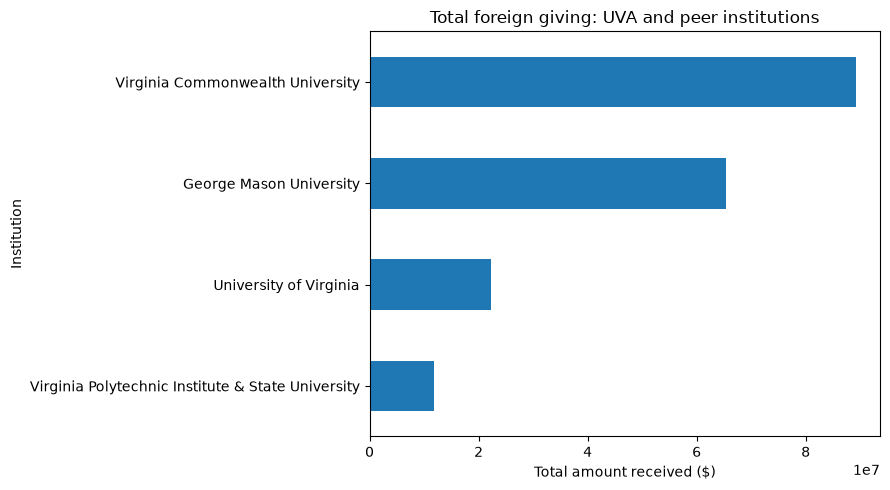

In [8]:
peer_table['sum'].sort_values().plot(kind='barh', figsize=(9, 5))
plt.title('Total foreign giving: UVA and peer institutions')
plt.xlabel('Total amount received ($)')
plt.ylabel('Institution')
plt.tight_layout()
plt.show()

In [9]:
peer_median_total = peer_table.loc[peers, 'sum'].median()
peer_median_count = peer_table.loc[peers, 'count'].median()
gap_to_peer_median = peer_median_total - uva_total

print(f'Peer median total: ${peer_median_total:,.0f}')
print(f'UVA gap to peer median: ${gap_to_peer_median:,.0f}')
print(f'Peer median gift count: {peer_median_count:,.0f}')

Peer median total: $65,435,604
UVA gap to peer median: $43,246,366
Peer median gift count: 38


UVA is below George Mason University and Virginia Commonwealth University by total dollars, but it is above Virginia Tech. The peer median is **65.4 million dollars and 38 gifts**, compared with UVA total of **22.2 million dollars and 98 gifts**. UVA is about **43.2 million dollars below** the peer median in total dollars, although UVA has more reported transactions than the peer median (George Mason).

## Comparison with the overall market

In [10]:
market_totals = df.groupby('Institution Name')['Foreign Gift Amount'].sum()
market_rank = market_totals.rank(ascending=False, method='min')
market_median = market_totals.median()
percent_below_uva = (market_totals < uva_total).mean() * 100

print('Number of institutions:', len(market_totals))
print(f'Market median: ${market_median:,.0f}')
print(f'UVA rank: {market_rank["University of Virginia"]:.0f} of {len(market_totals)}')
print(f'Institutions below UVA: {percent_below_uva:.1f}%')

Number of institutions: 318
Market median: $6,486,792
UVA rank: 101 of 318
Institutions below UVA: 68.2%


UVA ranks 101st of 318 institutions by total foreign giving. Its 22.2 million dollars total is above the market median of 6.5 million dollars and above 68.2% of institutions.

## Finding new sources of foreign money

In [11]:
# AI help: I used AI to help compare peer-only countries with UVA.
peer_gifts = df[df['Institution Name'].isin(peers)]

# Find countries that gave to peers but do not appear in UVA's records.
peer_country_totals = peer_gifts.groupby('Country of Giftor')['Foreign Gift Amount'].agg(
    ['count', 'sum']
)
uva_country_names = uva['Country of Giftor'].unique()
country_opportunities = peer_country_totals[
    ~peer_country_totals.index.isin(uva_country_names)
]
country_opportunities = country_opportunities.sort_values('sum', ascending=False)
country_opportunities.head(10)

,count,sum
Country of Giftor,,
QATAR,12,79680363
SAUDI ARABIA,13,54196266
UNITED ARAB EMIRATES,13,7104720
GERMANY,11,2711552
SPAIN,5,2444366
INDIA,4,1485778
KUWAIT,4,1388173
CHINA,6,1170034
OMAN,2,1099939


In [17]:
# AI help: I used AI to help identify repeat peer giftors missing from UVA records.
# Find repeat giftors at peers that do not appear in UVA's records.
known_peer_giftors = peer_gifts.dropna(subset=['Giftor Name'])
giftor_opportunities = known_peer_giftors.groupby('Giftor Name').agg(
    peer_amount=('Foreign Gift Amount', 'sum'),
    number_of_gifts=('Foreign Gift Amount', 'count'),
    peer_institutions=('Institution Name', 'nunique')
)

uva_giftor_names = uva['Giftor Name'].dropna().unique()
giftor_opportunities = giftor_opportunities[
    ~giftor_opportunities.index.isin(uva_giftor_names)
]
giftor_opportunities = giftor_opportunities.sort_values(
    'peer_amount', ascending=False
)

# Repeat activity is a stronger lead than a single past gift.
repeat_giftors = giftor_opportunities[
    (giftor_opportunities['number_of_gifts'] >= 3) |
    (giftor_opportunities['peer_institutions'] >= 2)
]
repeat_giftors.head(10)

,peer_amount,number_of_gifts,peer_institutions
Giftor Name,,,
Qatar Foundation,78285875,3,1
Royal Embassy of Saudi Arabia,54183796,12,1
Embassy of the United Arab Emirates,4406188,6,1
Boehringer Ingelheim Pharmaceutical,1489324,5,1
Embassy of the State of Kuwait,1388173,4,1
Astra Zeneca,820331,3,1
GW Pharmaceuticals,699969,3,1
"Grifols, Inc.",675859,3,1
Qatar National Research Fund,573533,6,1


In [18]:
# AI help: I used AI to check the simple capture-rate benchmark calculation.
top_five_country_total = country_opportunities.head(5)['sum'].sum()
one_percent_benchmark = top_five_country_total * 0.01
five_percent_benchmark = top_five_country_total * 0.05

print(f'Peer giving from top five countries: ${top_five_country_total:,.0f}')
print(f'1% capture benchmark: ${one_percent_benchmark:,.0f}')
print(f'5% capture benchmark: ${five_percent_benchmark:,.0f}')

Peer giving from top five countries: $146,137,267
1% capture benchmark: $1,461,373
5% capture benchmark: $7,306,863


## Proposed strategy

UVA should use a evidence-based prospect list rather than broadly approaching every country.

1. **Prioritize country gaps.** Qatar, Saudi Arabia, the United Arab Emirates, Germany, and Spain gave in-state peers a combined 146.1 million dollars but do not appear in UVA country records. These are the first markets to investigate.
2. **Prioritize repeat institutional giftors.** Begin with organizations that made at least three peer gifts or supported at least two peers. Examples include Qatar Foundation, the Royal Embassy of Saudi Arabia, and the Embassy of the United Arab Emirates.

3. **Use a measurable first-stage goal.** A 1% share of the 146.1 million dollars peer-country opportunity equals about 1.5 million dollars. A 5% share equals 7.3 million dollars. UVA could target the top 10 repeat organizations and build proposals totaling 1.5 million dollars.
